# Protocol 4 — Direct Handoff

Agents pass control directly to each other — **no supervisor**.  
Each agent's last act is writing the name of its successor into `state["next"]`.

```
outline_agent  →  "next": "draft_agent"
draft_agent    →  "next": "refine_agent"
refine_agent   →  "next": "END"
```

**How it works:**
- Each agent knows exactly who comes after it — hardcoded
- The graph's conditional edges just read `state["next"]` and follow it
- No LLM routing call, no supervisor round-trip, no tool-call overhead

This protocol is essentially a **directed pipeline**: A → B → C → END

In [1]:
# Cell 1: Setup
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

c:\Users\shiva\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## State: `next` is the handoff signal

`next` is the only routing mechanism — each agent sets it to its successor's name.  
There is no supervisor reading it and deciding; the graph just follows it directly.

Compare to previous protocols:

| Protocol | Who decides `next`? |
|----------|---------------------|
| Protocol 1/2 | The supervisor LLM |
| Protocol 3   | The LLM's tool-call output |
| **Protocol 4** | **Each agent itself — hardcoded** |

In [2]:
# Cell 2: State
class State(TypedDict):
    messages: list
    next: str  # Each agent writes the name of its own successor here

## The Pipeline: Report Generation

We build a 3-stage report generation pipeline:

```
User topic
    │
    ▼
outline_agent   — produces 3 key points
    │  sets next = "draft_agent"
    ▼
draft_agent     — writes a paragraph per point
    │  sets next = "refine_agent"
    ▼
refine_agent    — polishes tone and clarity
    │  sets next = "END"
    ▼
   END
```

Notice: each agent **hardcodes** its successor's name. That is the defining trait of Protocol 4.

In [3]:
# Cell 3: outline_agent — Stage 1
# Reads the user's topic, generates 3 key points, hands off to draft_agent
def outline_agent(state: State) -> State:
    topic = next(m for m in state["messages"] if isinstance(m, HumanMessage)).content
    response = llm.invoke([
        SystemMessage(content="Generate exactly 3 concise key points about this topic. Number them 1. 2. 3."),
        HumanMessage(content=topic)
    ])
    outline_msg = AIMessage(content=f"[Outline]\n{response.content}")
    return {
        "messages": state["messages"] + [outline_msg],
        "next": "draft_agent"  # hardcoded handoff — outline always goes to draft
    }

In [4]:
# Cell 4: draft_agent — Stage 2
# Reads the outline from messages, writes a short draft, hands off to refine_agent
def draft_agent(state: State) -> State:
    # The outline is always the last message when this agent runs
    outline = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="Write a short, engaging paragraph for each of the 3 key points below."),
        HumanMessage(content=outline)
    ])
    draft_msg = AIMessage(content=f"[Draft]\n{response.content}")
    return {
        "messages": state["messages"] + [draft_msg],
        "next": "refine_agent"  # hardcoded handoff — draft always goes to refine
    }

In [5]:
# Cell 5: refine_agent — Stage 3 (final)
# Reads the draft, polishes it, and sets next = "END" — the chain stops here
def refine_agent(state: State) -> State:
    draft = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="Polish this draft for clarity and professional tone. Keep it concise."),
        HumanMessage(content=draft)
    ])
    final_msg = AIMessage(content=f"[Final Report]\n{response.content}")
    return {
        "messages": state["messages"] + [final_msg],
        "next": "END"  # hardcoded terminal — refine is always the last stage
    }

## Routing: the graph just reads `state["next"]`

The routing function is trivial — it's a pure passthrough.  
All the routing decisions live **inside the agents**, not in the graph.

This is the sharpest contrast with Protocols 1–3 where the graph or supervisor owned routing.

In [6]:
# Cell 6: Route function — pure passthrough, agents own all routing decisions
def route_next(state: State) -> str:
    return END if state["next"] == "END" else state["next"]

In [7]:
# Cell 7: Build the graph
builder = StateGraph(State)

builder.add_node("outline_agent", outline_agent)
builder.add_node("draft_agent",   draft_agent)
builder.add_node("refine_agent",  refine_agent)

builder.set_entry_point("outline_agent")

# Each node routes to wherever the agent hardcoded in state["next"]
builder.add_conditional_edges("outline_agent", route_next, {
    "draft_agent": "draft_agent"
})
builder.add_conditional_edges("draft_agent", route_next, {
    "refine_agent": "refine_agent"
})
builder.add_conditional_edges("refine_agent", route_next, {
    END: END
})

app = builder.compile()

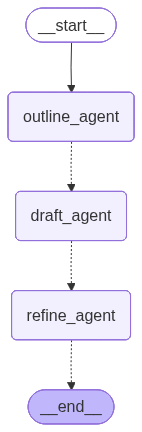

In [8]:
# Cell 8: Visualize — should look like a clean left-to-right chain
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Strength: No Supervisor Round-Trip

In Protocols 1–3, after every worker the flow returns to the supervisor for another LLM call.  
Protocol 4 skips that entirely:

```
Protocol 2:   outline → supervisor → draft → supervisor → refine → supervisor → END
              (6 hops, 3 supervisor LLM calls)

Protocol 4:   outline → draft → refine → END
              (3 hops, 0 supervisor LLM calls)
```

For a fixed, known pipeline this is strictly faster and cheaper.

In [9]:
# Cell 9: Run the pipeline and inspect every stage
topic = "The impact of sleep deprivation on decision making"

final_state = app.invoke({
    "messages": [HumanMessage(content=topic)],
    "next": ""
})

print("=" * 60)
print("  FULL HANDOFF TRAIL")
print("=" * 60)
for i, msg in enumerate(final_state["messages"]):
    label = "  User   " if isinstance(msg, HumanMessage) else "  Agent  "
    # Print only the first 120 chars of each message to keep output readable
    preview = msg.content.replace("\n", " ")[:120]
    print(f"[{i+1}]{label}: {preview}..." if len(msg.content) > 120 else f"[{i+1}]{label}: {msg.content}")

  FULL HANDOFF TRAIL
[1]  User   : The impact of sleep deprivation on decision making
[2]  Agent  : [Outline] 1. Sleep deprivation impairs cognitive functions, leading to decreased attention, increased risk of errors, an...
[3]  Agent  : [Draft] 1. Sleep deprivation doesn’t just leave you yawning in the morning; it significantly impairs your cognitive func...
[4]  Agent  : [Final Report] 1. Sleep deprivation extends beyond mere morning yawning; it critically impairs cognitive functions. Oper...


In [10]:
# Cell 10: Print the final polished report in full
final_report = final_state["messages"][-1].content
print(final_report)

[Final Report]
1. Sleep deprivation extends beyond mere morning yawning; it critically impairs cognitive functions. Operating on little sleep diminishes attention, increases the likelihood of overlooking important details, and heightens error rates. This cognitive fog can turn straightforward problem-solving tasks into significant challenges, ultimately compromising decision-making quality. By depriving ourselves of sleep, we undermine our capacity for clear thinking and informed choices.

2. Insufficient sleep can lead to heightened emotional responses and diminished impulse control. When we are sleep-deprived, our emotional reactions may become exaggerated, resulting in erratic judgments and increased risk-taking behavior. Individuals lacking adequate rest often make impulsive decisions without considering the consequences, which can lead to regrettable actions. In such states, every choice resembles a gamble rather than a deliberate decision.

3. Chronic sleep deprivation functions 

## Weakness: Tight Coupling Between Agents

Each agent **hardcodes** the name of its successor. This creates tight coupling:

**Scenario:** You want to add a `fact_check_agent` between `draft_agent` and `refine_agent`.

In Protocol 2 (supervisor): update the supervisor prompt. One change.

In Protocol 4 (direct handoff): you must touch **multiple agents**:

```python
# Step 1 — write the new agent
def fact_check_agent(state):  
    ...  
    return {..., "next": "refine_agent"}   # knows about refine_agent

# Step 2 — modify draft_agent's hardcoded handoff
def draft_agent(state):
    ...  
    return {..., "next": "fact_check_agent"}  # was "refine_agent"

# Step 3 — update the graph wiring
builder.add_conditional_edges("draft_agent", route_next, {
    "fact_check_agent": "fact_check_agent"   # was "refine_agent"
})
```

Every agent knows its neighbour's **name**. Rename any agent and you must update every agent that points to it.

In [11]:
# Cell 11: Demonstrate tight coupling — insert fact_check_agent
def fact_check_agent(state: State) -> State:
    draft = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="Review this draft for any factual inaccuracies. Flag issues or confirm it looks accurate."),
        HumanMessage(content=draft)
    ])
    check_msg = AIMessage(content=f"[Fact Check]\n{response.content}")
    return {
        "messages": state["messages"] + [check_msg],
        "next": "refine_agent"  # this agent must know refine_agent exists
    }

# We also need to modify draft_agent to point to fact_check_agent instead
def draft_agent_v2(state: State) -> State:
    outline = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="Write a short, engaging paragraph for each of the 3 key points below."),
        HumanMessage(content=outline)
    ])
    draft_msg = AIMessage(content=f"[Draft]\n{response.content}")
    return {
        "messages": state["messages"] + [draft_msg],
        "next": "fact_check_agent"  # changed from "refine_agent" — this is the coupling
    }

# Rebuild the graph with the new agent inserted
builder2 = StateGraph(State)
builder2.add_node("outline_agent",    outline_agent)
builder2.add_node("draft_agent",      draft_agent_v2)    # updated version
builder2.add_node("fact_check_agent", fact_check_agent)  # new
builder2.add_node("refine_agent",     refine_agent)

builder2.set_entry_point("outline_agent")
builder2.add_conditional_edges("outline_agent",    route_next, {"draft_agent": "draft_agent"})
builder2.add_conditional_edges("draft_agent",      route_next, {"fact_check_agent": "fact_check_agent"})
builder2.add_conditional_edges("fact_check_agent", route_next, {"refine_agent": "refine_agent"})
builder2.add_conditional_edges("refine_agent",     route_next, {END: END})

app2 = builder2.compile()

print("Changes needed to insert one agent:")
print("  1. Write fact_check_agent (hardcode 'next': 'refine_agent')")
print("  2. Modify draft_agent    (change 'next' from 'refine_agent' to 'fact_check_agent')")
print("  3. Update graph wiring   (add new node + new conditional edge)")
print()
print("In a supervisor-based protocol you'd only update the supervisor prompt.")

Changes needed to insert one agent:
  1. Write fact_check_agent (hardcode 'next': 'refine_agent')
  2. Modify draft_agent    (change 'next' from 'refine_agent' to 'fact_check_agent')
  3. Update graph wiring   (add new node + new conditional edge)

In a supervisor-based protocol you'd only update the supervisor prompt.


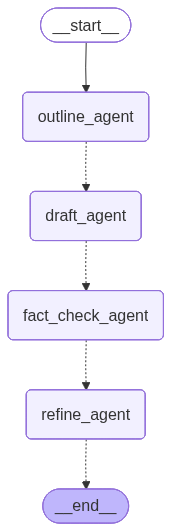

In [12]:
# Cell 12: Visualize the extended pipeline
display(Image(app2.get_graph().draw_mermaid_png()))

In [13]:
# Cell 13: Run the 4-stage pipeline
final_state2 = app2.invoke({
    "messages": [HumanMessage(content=topic)],
    "next": ""
})

print("=" * 60)
print("  4-STAGE PIPELINE TRAIL")
print("=" * 60)
for i, msg in enumerate(final_state2["messages"]):
    label = "  User   " if isinstance(msg, HumanMessage) else "  Agent  "
    # Show just the tag (first line) so the output stays clean
    first_line = msg.content.splitlines()[0]
    print(f"[{i+1}]{label}: {first_line}")

  4-STAGE PIPELINE TRAIL
[1]  User   : The impact of sleep deprivation on decision making
[2]  Agent  : [Outline]
[3]  Agent  : [Draft]
[4]  Agent  : [Fact Check]
[5]  Agent  : [Final Report]


## Summary

| Aspect | Protocol 4 Behavior |
|--------|---------------------|
| **Routing** | Each agent hardcodes its own successor |
| **Supervisor** | None — agents call the shots |
| **Latency** | Lowest — no supervisor round-trip |
| **Flexibility** | Low — inserting/reordering agents touches multiple files |
| **Coupling** | Tight — agents know each other by name |
| **Best for** | Fixed, predictable linear pipelines (ETL, content generation, processing chains) |

---

### Protocol Comparison So Far

```
Protocol 1/2 — Supervisor + shared state
    Hub-and-spoke: all roads go through the supervisor
    Flexible, but extra latency on every hop

Protocol 3 — Tool Calls
    LLM's function-calling IS the router
    Structured inputs, parallel calls, but workers are just functions

Protocol 4 — Direct Handoff
    No supervisor, agents chain themselves
    Fastest for fixed pipelines, but tightly coupled
```